In [ ]:
# --- Repo-root bootstrap: keep relative paths (data/..., common.validation) working
# regardless of where Jupyter's working directory starts out ---
import os, sys
from pathlib import Path

_root = Path.cwd()
while not (_root / ".git").exists() and _root.parent != _root:
    _root = _root.parent
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))


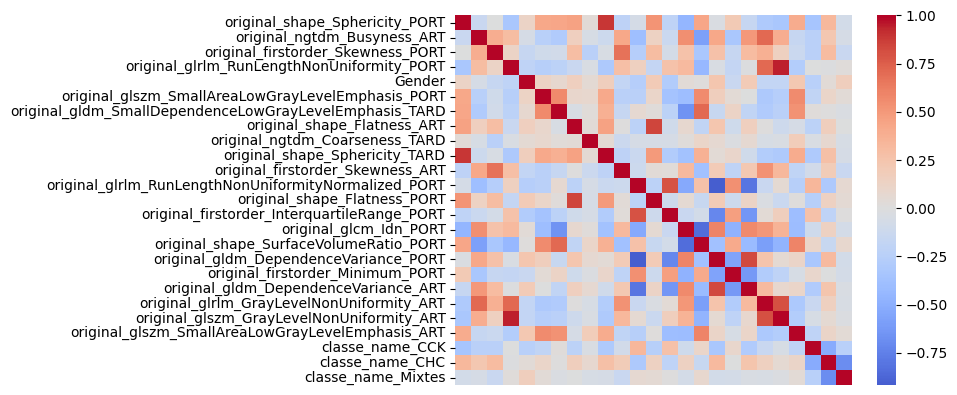

In [ ]:
import pandas as pd

import matplotlib.pyplot as plt


import seaborn as sns


df_res = pd.read_csv('data/flattened_global_scaled.csv', sep = ";")


cols_original = ["original_shape_Sphericity_PORT", "original_ngtdm_Busyness_ART", "original_firstorder_Skewness_PORT", "original_glrlm_RunLengthNonUniformity_PORT", "Gender" , "original_glszm_SmallAreaLowGrayLevelEmphasis_PORT", "original_gldm_SmallDependenceLowGrayLevelEmphasis_TARD", "original_shape_Flatness_ART", "original_ngtdm_Coarseness_TARD", "original_shape_Sphericity_TARD", "original_firstorder_Skewness_ART", "original_glrlm_RunLengthNonUniformityNormalized_PORT", "original_shape_Flatness_PORT", "classe_name","original_firstorder_InterquartileRange_PORT", "original_glcm_Idn_PORT", "original_shape_SurfaceVolumeRatio_PORT", "original_gldm_DependenceVariance_PORT", "original_firstorder_Minimum_PORT", "original_gldm_DependenceVariance_ART", "original_glrlm_GrayLevelNonUniformity_ART", "original_glszm_GrayLevelNonUniformity_ART", "original_glszm_SmallAreaLowGrayLevelEmphasis_ART"]


df_corr = df_res[cols_original]


# One-hot encoding : transforme la colonne texte en 3 colonnes de 0 et 1

df_encoded = pd.get_dummies(df_corr, columns=['classe_name'], dtype=int)


# 2. Calcul de la nouvelle matrice de corrélation

corr_matrix_with_target = df_encoded.corr()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
import matplotlib.patches as mpatches

# =========================================================================
# 1. TES LISTES DE VARIABLES
# =========================================================================
features_commun = [
    "Gender", "original_firstorder_Skewness_ART", "original_firstorder_Skewness_PORT",
    "original_gldm_SmallDependenceLowGrayLevelEmphasis_TARD", "original_ngtdm_Busyness_ART",
    "original_ngtdm_Coarseness_TARD", "original_shape_Flatness_ART", "original_shape_Flatness_PORT",
    "original_shape_Sphericity_PORT", "original_shape_Sphericity_TARD"
]

features_modele_1 = [
    "original_firstorder_InterquartileRange_PORT", "original_glcm_Idn_PORT",
    "original_glrlm_RunLengthNonUniformity_PORT", "original_glrlm_RunLengthNonUniformityNormalized_PORT",
    "original_glszm_SmallAreaLowGrayLevelEmphasis_PORT", "original_shape_SurfaceVolumeRatio_PORT"
]

features_modele_2 = [
    "original_firstorder_Minimum_PORT", "original_gldm_DependenceVariance_ART",
    "original_gldm_DependenceVariance_PORT", "original_glrlm_GrayLevelNonUniformity_ART",
    "original_glszm_GrayLevelNonUniformity_ART", "original_glszm_SmallAreaLowGrayLevelEmphasis_ART"
]

# =========================================================================
# 2. CALCUL DE L'APPARIEMENT OPTIMAL (EXCLUSIFS)
# =========================================================================
# Extraction de la sous-matrice de corrélation absolue pour les exclusifs
sub_corr = corr_matrix_with_target.loc[features_modele_1, features_modele_2].abs()

# Algorithme Hongrois (on cherche à maximiser la corrélation -> minimiser 1 - corr)
row_ind, col_ind = linear_sum_assignment(1 - sub_corr.values)

# =========================================================================
# 3. PRÉPARATION DE L'ALIGNE-MENT DES NODES (COMMUNS EN HAUT, EXCLUSIFS EN BAS)
# =========================================================================
# Pour un rendu propre, on met les caractéristiques communes en haut et les exclusifs en bas
left_nodes = features_commun + features_modele_1
right_nodes = features_commun + features_modele_2

# Mapping des coordonnées Y (on inverse l'ordre pour afficher le premier élément en haut)
left_map = {name: idx for idx, name in enumerate(reversed(left_nodes))}
right_map = {name: idx for idx, name in enumerate(reversed(right_nodes))}

# =========================================================================
# 4. TRACÉ DU BEAU GRAPHE BIPARTITE
# =========================================================================
fig, ax = plt.subplots(figsize=(14, 11))

# --- TRACÉ DES LIENS (EDGES) ---
# A. Liens communs (Auto-appariement)
for feat in features_commun:
    y_left = left_map[feat]
    y_right = right_map[feat]
    ax.plot([0, 1], [y_left, y_right], color='#2ecc71', linestyle='-', linewidth=3, alpha=0.6, zorder=1)

# B. Liens exclusifs (Optimisés par le Lasso/Matching)
# On utilise un colormap pour exprimer la force de corrélation du match
cmap = plt.cm.plasma 

for r, c in zip(row_ind, col_ind):
    f1 = features_modele_1[r]
    f2 = features_modele_2[c]
    poids = sub_corr.iloc[r, c]
    
    y_left = left_map[f1]
    y_right = right_map[f2]
    
    # Plus la corrélation est forte, plus la ligne est épaisse et colorée
    color_edge = cmap(poids) 
    lw = 1 + poids * 4
    
    ax.plot([0, 1], [y_left, y_right], color=color_edge, linestyle='--', linewidth=lw, alpha=0.8, zorder=2)

# --- TRACÉ DES POINTS (NODES) & TEXTES ---
# C. Côté Gauche (Modèle 1)
for name, y in left_map.items():
    is_common = name in features_commun
    node_color = '#27ae60' if is_common else '#2980b9'
    ax.scatter(0, y, color=node_color, s=180, edgecolor='black', linewidth=1, zorder=3)
    ax.text(-0.04, y, name, ha='right', va='center', fontsize=10, fontweight='bold', color='#2c3e50')

# D. Côté Droit (Modèle 2)
for name, y in right_map.items():
    is_common = name in features_commun
    node_color = '#27ae60' if is_common else '#e67e22'
    ax.scatter(1, y, color=node_color, s=180, edgecolor='black', linewidth=1, zorder=3)
    ax.text(1.04, y, name, ha='left', va='center', fontsize=10, fontweight='bold', color='#2c3e50')

# --- CONFIGURATION ESTHÉTIQUE DE LAFIGURE ---
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-1, len(left_nodes))
ax.axis('off') # Supprime les axes inutiles

# Titre principal
ax.set_title("Graphe d'Appariement Bipartite des Caractéristiques Radiomiques", fontsize=14, fontweight='bold', pad=30)

# Sous-titres des colonnes
ax.text(0, len(left_nodes) - 0.3, "MODÈLE 1\n(Variables + Noyau Commun)", ha='center', va='bottom', fontsize=12, fontweight='bold', color='#2980b9')
ax.text(1, len(right_nodes) - 0.3, "MODÈLE 2\n(Variables + Noyau Commun)", ha='center', va='bottom', fontsize=12, fontweight='bold', color='#e67e22')

# --- LÉGENDE INTERPRÉTATIVE ---
patch_m1 = mpatches.Patch(color='#2980b9', label='Exclusif Modèle 1')
patch_m2 = mpatches.Patch(color='#e67e22', label='Exclusif Modèle 2')
patch_com = mpatches.Patch(color='#27ae60', label='Noyau Commun (Stable)')
line_com = plt.Line2D([0], [0], color='#2ecc71', linewidth=3, label='Match Commun (Corr = 1.0)')
line_exc = plt.Line2D([0], [0], color='purple', linestyle='--', linewidth=2, label='Match Optimisé (Bipartite Weight)')

ax.legend(handles=[patch_m1, patch_m2, patch_com, line_com, line_exc], loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=10, frameon=True)

# Ajout d'une barre de couleur pour l'intensité des liens exclusifs
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', shrink=0.4, pad=0.05)
cbar.set_label("Force du couplage (Valeur absolue de la corrélation)", fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# =========================================================================
# 5. GÉNÉRATION DU TABLEAU DE SYNTHÈSE POUR TON RAPPORT
# =========================================================================
print("\n📋 TABLEAU COMPLÈTE DU MATCHING (COMMUNS + EXCLUSIFS) :")
print("-" * 80)
matching_complet = []
for f in features_commun:
    matching_complet.append({"Variable Modèle 1": f, "Variable Modèle 2": f, "Type": "Noyau Commun", "Corrélation": 1.0})

for r, c in zip(row_ind, col_ind):
    f1 = features_modele_1[r]
    f2 = features_modele_2[c]
    matching_complet.append({"Variable Modèle 1": f1, "Variable Modèle 2": f2, "Type": "Match Optimisé", "Corrélation": round(sub_corr.iloc[r, c], 3)})

df_matching_final = pd.DataFrame(matching_complet)
display(df_matching_final.sort_values(by="Corrélation", ascending=False).reset_index(drop=True))